In [1]:
!pip install imbalanced-learn --quiet

# Notebook 04: Supervised Machine Learning — Hospital Tier Prediction
**Project:** Predicting the DOH Hospital Tier Available per LGU from Socioeconomic + Healthcare + OSM Features

**Research Question:** *Can the socioeconomic profile of an LGU — its poverty rate, birth demand, population size, growth, healthcare capacity, and infrastructure density — predict the hospital tier it warrants? And which LGUs are structurally underserved?*

---

## Design Rationale

### Feature Set: Expanded to 17 Features

Based on exploratory analysis, three feature groups are used:

**Group A — Socioeconomic (9 features)**
- Population (2020, 2024), growth rate, births (both/male/female), poverty incidence (2018, 2021, 2023)

**Group B — Healthcare Capacity (5 features)**
- `facility_density_per10k`, `weighted_score_per10k`, `beds_per_1000`, `hospital_density_per10k`, `private_ownership_pct`
- *Note: hospital_count_level1/2/3 are excluded — they define the target and cannot be features.*

**Group C — OSM Infrastructure (3 features)**
- `pharmacy`, `school`, `place_of_worship` (lowest sparsity among OSM columns, ≤51% zeros)
- Dropped: hospital-derived totals, highly sparse OSM columns (>75% zeros)

### Why PCA on the 17 features?

PCA reduces collinearity (population 2020/2024 are near-identical; all three poverty years are correlated; birth columns are near-linear combinations). The first N components explaining ≥90% of variance are selected automatically.

### Target: Ordinal Hospital Tier

| Tier | Definition | LGUs | % |
|------|-----------|------|---|
| 0 | No hospital | 1,339 | 82.2% |
| 1 | ≥1 Level 1 | 196 | 12.0% |
| 2 | ≥1 Level 2 | 73 | 4.5% |
| 3 | ≥1 Level 3 | 21 | 1.3% |

All models use `class_weight='balanced'` to address class imbalance.

## Notebook Structure

| # | Section |
|---|---------|
| 1 | Setup and Data Loading |
| 2 | Feature Engineering and Imputation |
| 3 | Target Variable |
| 4 | Standardisation and PCA |
| 5 | Train / Test Split |
| 6 | kNN Classification |
| 7 | Logistic Regression — L2 |
| 8 | Logistic Regression — L1 (liblinear, OvR) |
| 9 | Random Forest |
| 10 | Gradient Boosted Trees |
| 11 | Model Comparison |
| 12 | Underserved LGU Identification |
| 13 | Novelty — Expected Tier and Poverty Equity Analysis |
| 14 | Conclusion |


---
## 1. Setup and Data Loading


In [2]:
import warnings
warnings.filterwarnings('ignore')

import os, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (f1_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)
from imblearn.over_sampling import SMOTE

print("Libraries loaded.")

Libraries loaded.


In [3]:
DB_PATH   = os.path.join('data', 'processed', 'hospital_data.db')
XLSX_PATH = os.path.join('data', 'clean', 'final_dataset_clean.xlsx')

if os.path.exists(DB_PATH):
    conn = sqlite3.connect(DB_PATH)
    df   = pd.read_sql('SELECT * FROM lgu_merged', conn)
    conn.close()
    print(f"Loaded from SQLite: {df.shape[0]} LGUs x {df.shape[1]} cols")
else:
    df = pd.read_excel(XLSX_PATH)
    if 'province_x' in df.columns:
        df = df.rename(columns={'province_x': 'province'})
    print(f"Loaded from XLSX: {df.shape[0]} LGUs x {df.shape[1]} cols")


Loaded from SQLite: 1629 LGUs x 50 cols


---
## 2. Feature Engineering and Imputation

In [4]:
# ── 17 features across 3 groups ───────────────────────────────────────────
# Group A: Socioeconomic (9)
FEATURES_SOCIO = [
    'population_2020',
    'population_2024',
    'pop_growth_rate_pct',
    'poverty_incidence_2018_pct',
    'poverty_incidence_2021_pct',
    'poverty_incidence_2023_pct',
    'births_residence_both',
    'births_residence_male',
    'births_residence_female',
]
# Group B: Healthcare capacity (5) — hospital_count_level* EXCLUDED (they define the target)
FEATURES_HEALTH = [
    'facility_density_per10k',
    'weighted_score_per10k',
    'beds_per_1000',
    'hospital_density_per10k',
    'private_ownership_pct',
]
# Group C: OSM infrastructure (3) — lowest sparsity among OSM columns
FEATURES_OSM = [
    'pharmacy',
    'school',
    'place_of_worship',
]

FEATURES = FEATURES_SOCIO + FEATURES_HEALTH + FEATURES_OSM
print(f"Total features: {len(FEATURES)}")
for g, grp in [('A — Socioeconomic', FEATURES_SOCIO),
               ('B — Healthcare Capacity', FEATURES_HEALTH),
               ('C — OSM Infrastructure', FEATURES_OSM)]:
    print(f"\n  Group {g}:")
    for f in grp:
        print(f"    {f}")
print()
print("Excluded: hospital_count_level1/2/3 (define the target, not features)")
print("Excluded: total_hospitals, total_facilities, weighted_facility_score (derived from target)")
print("Excluded: high-sparsity OSM cols (>75% zeros: bar, parking, shelter, toilets, etc.)")


Total features: 17

  Group A — Socioeconomic:
    population_2020
    population_2024
    pop_growth_rate_pct
    poverty_incidence_2018_pct
    poverty_incidence_2021_pct
    poverty_incidence_2023_pct
    births_residence_both
    births_residence_male
    births_residence_female

  Group B — Healthcare Capacity:
    facility_density_per10k
    weighted_score_per10k
    beds_per_1000
    hospital_density_per10k
    private_ownership_pct

  Group C — OSM Infrastructure:
    pharmacy
    school
    place_of_worship

Excluded: hospital_count_level1/2/3 (define the target, not features)
Excluded: total_hospitals, total_facilities, weighted_facility_score (derived from target)
Excluded: high-sparsity OSM cols (>75% zeros: bar, parking, shelter, toilets, etc.)


In [5]:
# ── Impute: regional median, then global median fallback ─────────────────────
IMPUTE_COLS = [
    # Socioeconomic
    'poverty_incidence_2018_pct', 'poverty_incidence_2021_pct', 'poverty_incidence_2023_pct',
    'births_residence_both', 'births_residence_male', 'births_residence_female',
    # Healthcare capacity — fill missing with 0 (no facility = 0 density)
    'facility_density_per10k', 'weighted_score_per10k', 'beds_per_1000',
    'hospital_density_per10k', 'private_ownership_pct',
    # OSM — fill missing with 0 (no record = no facility)
    'pharmacy', 'school', 'place_of_worship',
]

ZERO_FILL_COLS = [
    'facility_density_per10k', 'weighted_score_per10k', 'beds_per_1000',
    'hospital_density_per10k', 'private_ownership_pct',
    'pharmacy', 'school', 'place_of_worship',
]

# Regional median imputation for poverty and births
for col in ['poverty_incidence_2018_pct', 'poverty_incidence_2021_pct', 'poverty_incidence_2023_pct',
            'births_residence_both', 'births_residence_male', 'births_residence_female']:
    if col in df.columns:
        reg_med = df.groupby('region')[col].transform('median')
        df[col]  = df[col].fillna(reg_med).fillna(df[col].median())

# Zero-fill for capacity/OSM (absence = 0)
for col in ZERO_FILL_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Check which FEATURES are actually present in the dataframe
FEATURES = [f for f in FEATURES if f in df.columns]
print(f"Features available after checking columns: {len(FEATURES)}")
missing_feats = [f for f in (FEATURES_SOCIO + FEATURES_HEALTH + FEATURES_OSM) if f not in df.columns]
if missing_feats:
    print(f"  WARNING — not found in dataframe: {missing_feats}")
print(f"Missing values after imputation: {df[FEATURES].isnull().sum().sum()}")


Features available after checking columns: 17
Missing values after imputation: 0


---
## 3. Target Variable: Ordinal Hospital Tier

In [6]:
# ── Construct ordinal tier ──────────────────────────────────────────────
df['tier'] = 0
df.loc[df['hospital_count_level1'] >= 1, 'tier'] = 1
df.loc[df['hospital_count_level2'] >= 1, 'tier'] = 2
df.loc[df['hospital_count_level3'] >= 1, 'tier'] = 3

_cols = list(dict.fromkeys(
    FEATURES + ['tier', 'city_municipality', 'region', 'poverty_incidence_2023_pct']
))
model_df = df[_cols].dropna(subset=FEATURES).copy().reset_index(drop=True)
print(f"Working dataset: {len(model_df)} LGUs")
print()
vc = model_df['tier'].value_counts().sort_index()
labels = {0:'No hospital', 1:'Level 1 (primary)', 2:'Level 2 (secondary)', 3:'Level 3 (tertiary)'}
for t, cnt in vc.items():
    print(f"  Tier {t} — {labels[t]:<26}  {cnt:>5} LGUs  ({cnt/len(model_df)*100:.1f}%)")


Working dataset: 1629 LGUs

  Tier 0 — No hospital                  1279 LGUs  (78.5%)
  Tier 1 — Level 1 (primary)             214 LGUs  (13.1%)
  Tier 2 — Level 2 (secondary)           100 LGUs  (6.1%)
  Tier 3 — Level 3 (tertiary)             36 LGUs  (2.2%)


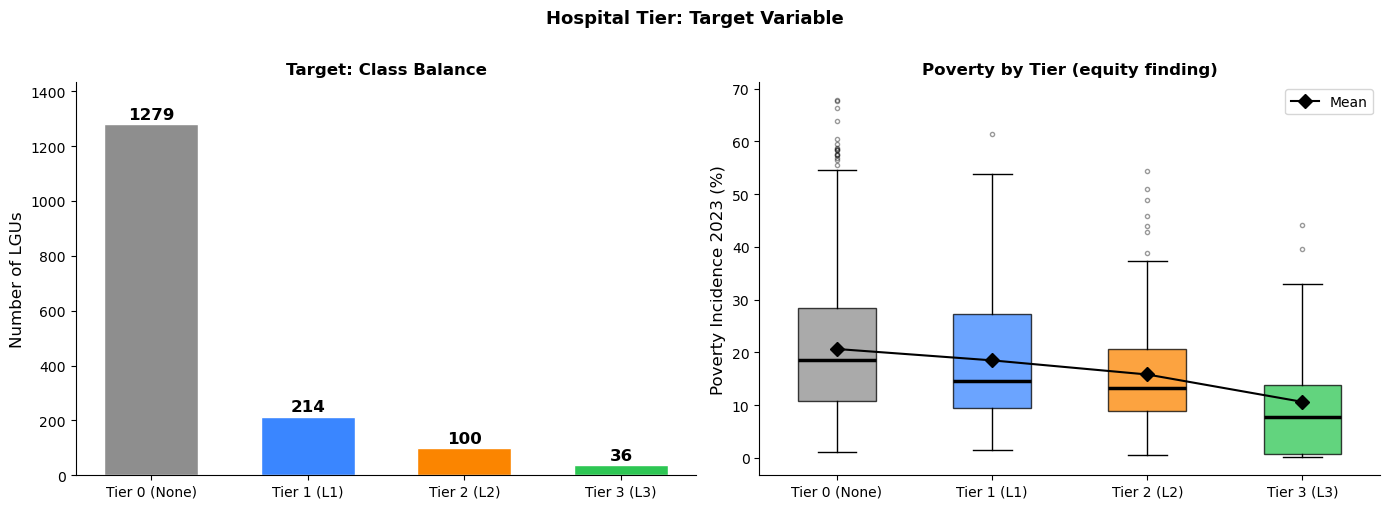

Poverty decreases monotonically with tier:
  Tier 0: mean=20.7%  median=18.7%
  Tier 1: mean=18.5%  median=14.5%
  Tier 2: mean=15.8%  median=13.3%
  Tier 3: mean=10.6%  median=7.7%


In [7]:
# ── Visualise: tier distribution and poverty by tier ─────────────────────
TIER_COLORS = ['#8e8e8e', '#3a86ff', '#fb8500', '#2dc653']
TIER_LBLS   = ['Tier 0 (None)', 'Tier 1 (L1)', 'Tier 2 (L2)', 'Tier 3 (L3)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = model_df['tier'].value_counts().sort_index()
bars = axes[0].bar(TIER_LBLS, counts.values, color=TIER_COLORS, edgecolor='white', width=0.6)
for bar, cnt in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 str(cnt), ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of LGUs', fontsize=12)
axes[0].set_title('Target: Class Balance', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, counts.max() * 1.12)
axes[0].spines[['top', 'right']].set_visible(False)

pov_data = [model_df[model_df['tier'] == t]['poverty_incidence_2023_pct'].dropna().values
            for t in range(4)]
bp = axes[1].boxplot(pov_data, labels=TIER_LBLS, patch_artist=True, widths=0.5,
                      medianprops=dict(color='black', linewidth=2.5),
                      flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, c in zip(bp['boxes'], TIER_COLORS):
    patch.set_facecolor(c); patch.set_alpha(0.75)
means = [v.mean() for v in pov_data]
axes[1].plot(range(1, 5), means, 'D-', color='black', ms=7, zorder=5, label='Mean')
axes[1].set_ylabel('Poverty Incidence 2023 (%)', fontsize=12)
axes[1].set_title('Poverty by Tier (equity finding)', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Hospital Tier: Target Variable', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print("Poverty decreases monotonically with tier:")
for t, vals in enumerate(pov_data):
    print(f"  Tier {t}: mean={vals.mean():.1f}%  median={np.median(vals):.1f}%")


---
## 4. Standardisation and PCA

This section connects directly to `03_preprocessing.py`. PCA is applied to all 17 features.  
Unlike the original 9-feature PCA (which gave 4 fixed components), the number of components here is chosen automatically to explain **≥90% of variance**.

The expanded feature set captures more signal:
- Healthcare capacity features (facility density, beds) load on components distinct from socioeconomic dimensions
- OSM features (pharmacy, school, place_of_worship) contribute to urbanisation / infrastructure components

The resulting PCs are used as input to all five models.


In [8]:
# ── Standardise (fit on train, transform both) ────────────────────────────
X_all = model_df[FEATURES]
y_all = model_df['tier']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.25, random_state=42, stratify=y_all
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_test_sc  = scaler.transform(X_test_raw)
X_all_sc   = scaler.transform(X_all)

print("Standardisation: fit on training set only.")
print(f"  Train: {X_train_sc.shape}  Test: {X_test_sc.shape}")
print()

# ── SMOTE: bring T1, T2, T3 all up to 50% of T0 count ────────────────────
t0_count = (y_train == 0).sum()
smote_target = t0_count // 2  # 50% of majority class

smote_strategy = {
    1: max((y_train == 1).sum(), smote_target),
    2: max((y_train == 2).sum(), smote_target),
    3: max((y_train == 3).sum(), smote_target),
}
print("SMOTE sampling strategy (training only):")
for t, n in smote_strategy.items():
    before = (y_train == t).sum()
    print(f"  Tier {t}: {before} → {n} samples")

sm = SMOTE(sampling_strategy=smote_strategy, random_state=42, k_neighbors=3)
X_train_sm, y_train_sm = sm.fit_resample(X_train_sc, y_train)

print(f"\nTraining set after SMOTE: {X_train_sm.shape[0]} samples")
for t in [0, 1, 2, 3]:
    n = (y_train_sm == t).sum()
    print(f"  Tier {t}: {n} ({n/len(y_train_sm)*100:.1f}%)")
print("\nTest set unchanged (no leakage):")
for t in [0, 1, 2, 3]:
    n = (y_test == t).sum()
    print(f"  Tier {t}: {n} ({n/len(y_test)*100:.1f}%)")

Standardisation: fit on training set only.
  Train: (1221, 17)  Test: (408, 17)

SMOTE sampling strategy (training only):
  Tier 1: 160 → 479 samples
  Tier 2: 75 → 479 samples
  Tier 3: 27 → 479 samples

Training set after SMOTE: 2396 samples
  Tier 0: 959 (40.0%)
  Tier 1: 479 (20.0%)
  Tier 2: 479 (20.0%)
  Tier 3: 479 (20.0%)

Test set unchanged (no leakage):
  Tier 0: 320 (78.4%)
  Tier 1: 54 (13.2%)
  Tier 2: 25 (6.1%)
  Tier 3: 9 (2.2%)


In [9]:
# ── PCA: fit on SMOTE train, transform all sets ───────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_train_sm)
evr_full     = pca_full.explained_variance_ratio_
cum_var_full = evr_full.cumsum()

n_components = int(np.argmax(cum_var_full >= 0.90)) + 1
print(f"Components needed to explain ≥90% variance: {n_components}")
print(f"  (out of {len(FEATURES)} total features)")
print()
print("Full explained variance per component:")
for i, (ev, cv) in enumerate(zip(evr_full, cum_var_full), 1):
    bar    = chr(9608) * int(ev * 40)
    marker = " <-- 90% threshold" if i == n_components else ""
    print(f"  PC{i:>2}: {ev*100:5.1f}%  cumulative: {cv*100:5.1f}%  {bar}{marker}")
    if cv > 0.98:
        break

pca          = PCA(n_components=n_components, random_state=42)
X_train_pca  = pca.fit_transform(X_train_sm)   # SMOTE train
X_test_pca   = pca.transform(X_test_sc)         # original test (no leakage)
X_all_pca    = pca.transform(X_all_sc)

evr = pca.explained_variance_ratio_
print()
print(f"PCA fit on {X_train_sm.shape[0]} SMOTE-resampled training LGUs.")
print(f"{n_components} PCs explain {evr.sum()*100:.1f}% of variance.")

# Build PC names from top-loading feature
pc_names = []
for i, row in enumerate(pca.components_):
    top_feat = FEATURES[np.argsort(np.abs(row))[::-1][0]]
    pc_names.append(f"PC{i+1} ({top_feat[:18]})")
print()
print("PC names (top-loading feature):")
for name, ev in zip(pc_names, evr):
    print(f"  {name:<32}  {ev*100:.1f}%")

# y_train for all model sweeps = SMOTE-resampled labels
y_train_sweep = y_train_sm

Components needed to explain ≥90% variance: 6
  (out of 17 total features)

Full explained variance per component:
  PC 1:  61.3%  cumulative:  61.3%  ████████████████████████
  PC 2:  12.2%  cumulative:  73.5%  ████
  PC 3:   6.2%  cumulative:  79.7%  ██
  PC 4:   4.4%  cumulative:  84.1%  █
  PC 5:   4.0%  cumulative:  88.1%  █
  PC 6:   3.6%  cumulative:  91.7%  █ <-- 90% threshold
  PC 7:   2.5%  cumulative:  94.2%  █
  PC 8:   1.7%  cumulative:  95.9%  
  PC 9:   1.3%  cumulative:  97.2%  
  PC10:   0.9%  cumulative:  98.1%  

PCA fit on 2396 SMOTE-resampled training LGUs.
6 PCs explain 91.7% of variance.

PC names (top-loading feature):
  PC1 (births_residence_m)          61.3%
  PC2 (beds_per_1000)               12.2%
  PC3 (beds_per_1000)               6.2%
  PC4 (facility_density_p)          4.4%
  PC5 (population_2020)             4.0%
  PC6 (pharmacy)                    3.6%


In [10]:
# ── PC loading matrix ────────────────────────────────────────────────────────
W_df = pd.DataFrame(pca.components_,
                    index=pc_names,
                    columns=FEATURES)

print("PC Loading Matrix (top 3 loadings per component):")
for pc in W_df.index:
    row = W_df.loc[pc].abs().sort_values(ascending=False)
    top = row.head(3)
    parts = [f"{feat}: {W_df.loc[pc, feat]:+.2f}" for feat in top.index]
    print(f"  {pc}: {' | '.join(parts)}")

print()
print("Full loading matrix:")
print(W_df.round(2).to_string())


PC Loading Matrix (top 3 loadings per component):
  PC1 (births_residence_m): births_residence_male: +0.44 | births_residence_both: +0.44 | births_residence_female: +0.44
  PC2 (beds_per_1000): beds_per_1000: +0.67 | private_ownership_pct: +0.39 | poverty_incidence_2021_pct: -0.27
  PC3 (beds_per_1000): beds_per_1000: +0.49 | poverty_incidence_2018_pct: +0.48 | poverty_incidence_2021_pct: +0.47
  PC4 (facility_density_p): facility_density_per10k: +0.48 | weighted_score_per10k: +0.48 | beds_per_1000: -0.32
  PC5 (population_2020): population_2020: +0.53 | population_2024: +0.52 | private_ownership_pct: -0.37
  PC6 (pharmacy): pharmacy: +0.53 | school: +0.51 | place_of_worship: +0.39

Full loading matrix:
                          population_2020  population_2024  pop_growth_rate_pct  poverty_incidence_2018_pct  poverty_incidence_2021_pct  poverty_incidence_2023_pct  births_residence_both  births_residence_male  births_residence_female  facility_density_per10k  weighted_score_per10k  bed

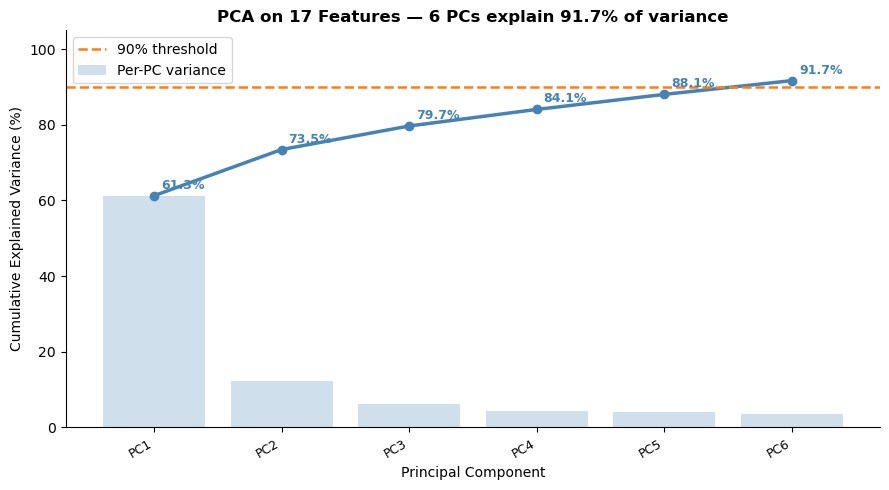

In [11]:
# ── Visualise: cumulative explained variance ──────────────────────────────
fig = plt.figure(figsize=(max(9, n_components * 1.2), 5))
cum_var = evr.cumsum()
x_ticks = range(1, n_components + 1)
plt.plot(x_ticks, cum_var * 100, marker='o', lw=2.5, color='steelblue')
plt.bar(x_ticks, evr * 100, color='steelblue', alpha=0.25, label='Per-PC variance')
plt.axhline(90, color='tab:orange', linestyle='--', lw=1.8, label='90% threshold')
for i, (ev, cv) in enumerate(zip(evr, cum_var), 1):
    plt.annotate(f'{cv*100:.1f}%', (i, cv*100), textcoords='offset points',
                 xytext=(5, 5), fontsize=9, color='steelblue', fontweight='bold')
plt.xticks(x_ticks, [n.split('(')[0].strip() for n in pc_names], rotation=30, ha='right', fontsize=9)
plt.ylabel('Cumulative Explained Variance (%)')
plt.xlabel('Principal Component')
plt.title(f'PCA on {len(FEATURES)} Features — {n_components} PCs explain {evr.sum()*100:.1f}% of variance', fontweight='bold')
plt.legend()
plt.ylim(0, 105)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()


---
## 5. Train / Test Split

In [12]:
print(f"Train (after SMOTE): {len(X_train_pca)} LGUs  |  Test (original): {len(X_test_pca)} LGUs  (75/25 split)")
print()
print(f"{'Tier':<8} {'Train n':>8} {'Train %':>9} {'Test n':>8} {'Test %':>9}")
print("-" * 44)
for t in [0, 1, 2, 3]:
    tr_n = (y_train_sweep == t).sum(); tr_p = tr_n / len(y_train_sweep) * 100
    te_n = (y_test == t).sum();        te_p = te_n / len(y_test) * 100
    print(f"  {t:<6} {tr_n:>8} {tr_p:>8.1f}% {te_n:>8} {te_p:>8.1f}%")
print()
print("All models use X_train_pca / X_test_pca. Scored with macro F1.")

Train (after SMOTE): 2396 LGUs  |  Test (original): 408 LGUs  (75/25 split)

Tier      Train n   Train %   Test n    Test %
--------------------------------------------
  0           959     40.0%      320     78.4%
  1           479     20.0%       54     13.2%
  2           479     20.0%       25      6.1%
  3           479     20.0%        9      2.2%

All models use X_train_pca / X_test_pca. Scored with macro F1.


---
## 6. Model 1 — k-Nearest Neighbors Classification

Following **Notebook 1A**: scan `n_neighbors` 1–40 over 20 seeds, plot training and test accuracy with error bars, select optimal `k`.


In [13]:
No_trials = 20

all_training_knn = pd.DataFrame()
all_test_knn     = pd.DataFrame()
n_neighbors_settings = range(1, 41)

for seedN in range(1, No_trials + 1):
    X_tr_raw, X_te_raw, y_tr_raw, y_te = train_test_split(
        X_all_sc, y_all, test_size=0.25, random_state=seedN, stratify=y_all
    )
    # Apply SMOTE per seed
    X_tr_sm, y_tr_sm = SMOTE(
        sampling_strategy={
            2: max((y_tr_raw == 2).sum(), (y_tr_raw == 1).sum() // 2),
            3: max((y_tr_raw == 3).sum(), (y_tr_raw == 1).sum() // 2),
        }, random_state=42, k_neighbors=3
    ).fit_resample(X_tr_raw, y_tr_raw)
    X_tr  = pca.transform(X_tr_sm)
    X_te  = pca.transform(X_te_raw)
    training_f1, test_f1 = [], []
    for k in n_neighbors_settings:
        knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
        knn.fit(X_tr, y_tr_sm)
        training_f1.append(f1_score(y_tr_sm, knn.predict(X_tr), average='macro', zero_division=0))
        test_f1.append(    f1_score(y_te,    knn.predict(X_te), average='macro', zero_division=0))
    all_training_knn[seedN] = training_f1
    all_test_knn[seedN]     = test_f1

best_k = list(n_neighbors_settings)[np.argmax(all_test_knn.mean(axis=1))]
print(f"Highest Average Test Macro F1 = {np.amax(all_test_knn.mean(axis=1)):.4f}")
print(f"Best n_neighbors = {best_k}")

Highest Average Test Macro F1 = 0.3699
Best n_neighbors = 3


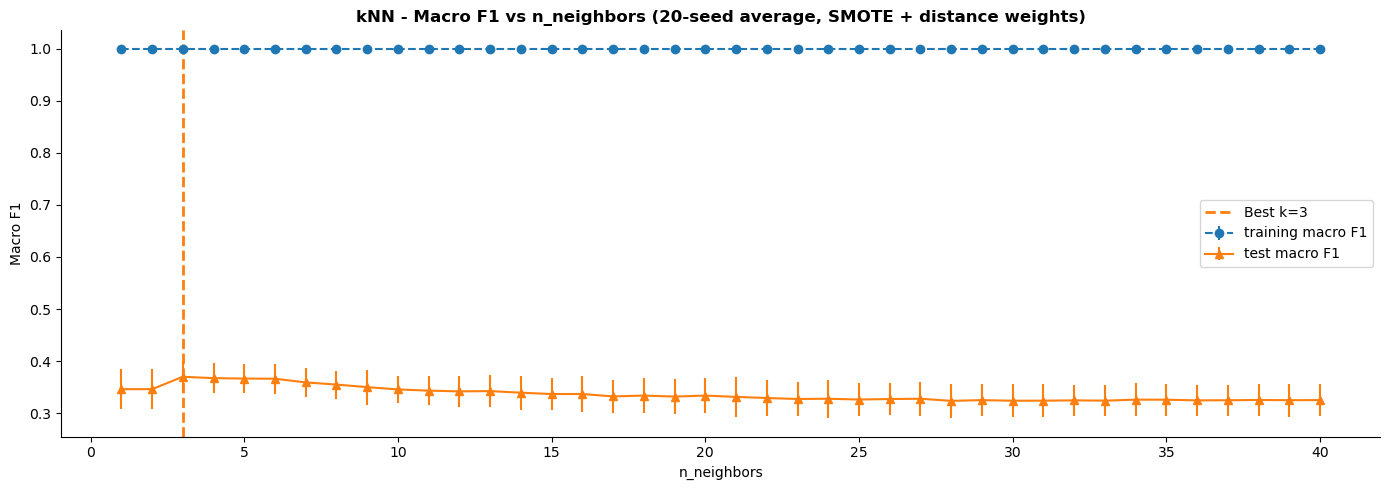

Decision: k=3 where test macro F1 peaks.


In [14]:
fig = plt.figure(figsize=(14, 5))
plt.errorbar(n_neighbors_settings, all_training_knn.mean(axis=1),
             yerr=all_training_knn.std(axis=1), label='training macro F1', marker='o', linestyle='dashed')
plt.errorbar(n_neighbors_settings, all_test_knn.mean(axis=1),
             yerr=all_test_knn.std(axis=1), label='test macro F1', marker='^')
plt.axvline(best_k, color='tab:orange', linestyle='--', lw=2, label=f'Best k={best_k}')
plt.ylabel('Macro F1')
plt.xlabel('n_neighbors')
plt.title(f'kNN - Macro F1 vs n_neighbors ({No_trials}-seed average, SMOTE + distance weights)', fontweight='bold')
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()
print(f"Decision: k={best_k} where test macro F1 peaks.")

In [15]:
knn_final = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
knn_final.fit(X_train_pca, y_train_sweep)

knn_train_f1 = f1_score(y_train_sweep, knn_final.predict(X_train_pca), average='macro', zero_division=0)
knn_test_f1  = f1_score(y_test,        knn_final.predict(X_test_pca),  average='macro', zero_division=0)
knn_sweep_f1 = all_test_knn.mean(axis=1).max()
knn_sweep_std = all_test_knn.std(axis=1).iloc[np.argmax(all_test_knn.mean(axis=1))]

print(f"kNN (k={best_k}, weights=distance)")
print(f"  [Sweep]  Test macro F1: {knn_sweep_f1:.4f} +/- {knn_sweep_std:.4f}")
print(f"  Train macro F1: {knn_train_f1:.4f}")
print(f"  Test  macro F1: {knn_test_f1:.4f}")
print()
print(classification_report(y_test, knn_final.predict(X_test_pca),
      target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))

kNN (k=3, weights=distance)
  [Sweep]  Test macro F1: 0.3699 +/- 0.0305
  Train macro F1: 1.0000
  Test  macro F1: 0.3546

              precision    recall  f1-score   support

      Tier 0       0.84      0.67      0.74       320
      Tier 1       0.22      0.31      0.26        54
      Tier 2       0.10      0.20      0.13        25
      Tier 3       0.19      0.56      0.29         9

    accuracy                           0.59       408
   macro avg       0.34      0.43      0.35       408
weighted avg       0.70      0.59      0.63       408



---
## 7. Model 2 — Logistic Regression with L2 Regularisation

Following **Notebook 3B**: scan `C` over a log-scale grid using 20 seeds. Higher `C` = less regularisation. `solver='lbfgs'` handles multiclass natively and is fast.


In [16]:
C_settings = [1e-5, 1e-3, 0.1, 0.2, 0.4, 0.75, 1, 1.5, 3, 5, 10, 15, 20, 100, 300, 1000, 10000]

all_training_lr2 = pd.DataFrame()
all_test_lr2     = pd.DataFrame()

for seedN in range(1, No_trials + 1):
    X_tr_raw, X_te_raw, y_tr_raw, y_te = train_test_split(
        X_all_sc, y_all, test_size=0.25, random_state=seedN, stratify=y_all
    )
    X_tr_sm, y_tr_sm = SMOTE(
        sampling_strategy={
            2: max((y_tr_raw == 2).sum(), (y_tr_raw == 1).sum() // 2),
            3: max((y_tr_raw == 3).sum(), (y_tr_raw == 1).sum() // 2),
        }, random_state=42, k_neighbors=3
    ).fit_resample(X_tr_raw, y_tr_raw)
    X_tr = pca.transform(X_tr_sm)
    X_te = pca.transform(X_te_raw)
    training_f1, test_f1 = [], []
    for C in C_settings:
        lr = LogisticRegression(C=C, class_weight='balanced',
                                solver='lbfgs', max_iter=1000, random_state=42)
        lr.fit(X_tr, y_tr_sm)
        training_f1.append(f1_score(y_tr_sm, lr.predict(X_tr), average='macro', zero_division=0))
        test_f1.append(    f1_score(y_te,    lr.predict(X_te), average='macro', zero_division=0))
    all_training_lr2[seedN] = training_f1
    all_test_lr2[seedN]     = test_f1

best_C_lr2 = C_settings[np.argmax(all_test_lr2.mean(axis=1))]
print(f"Highest Average Test Macro F1 = {np.amax(all_test_lr2.mean(axis=1)):.4f}")
print(f"Best C = {best_C_lr2}")

Highest Average Test Macro F1 = 0.3609
Best C = 1e-05


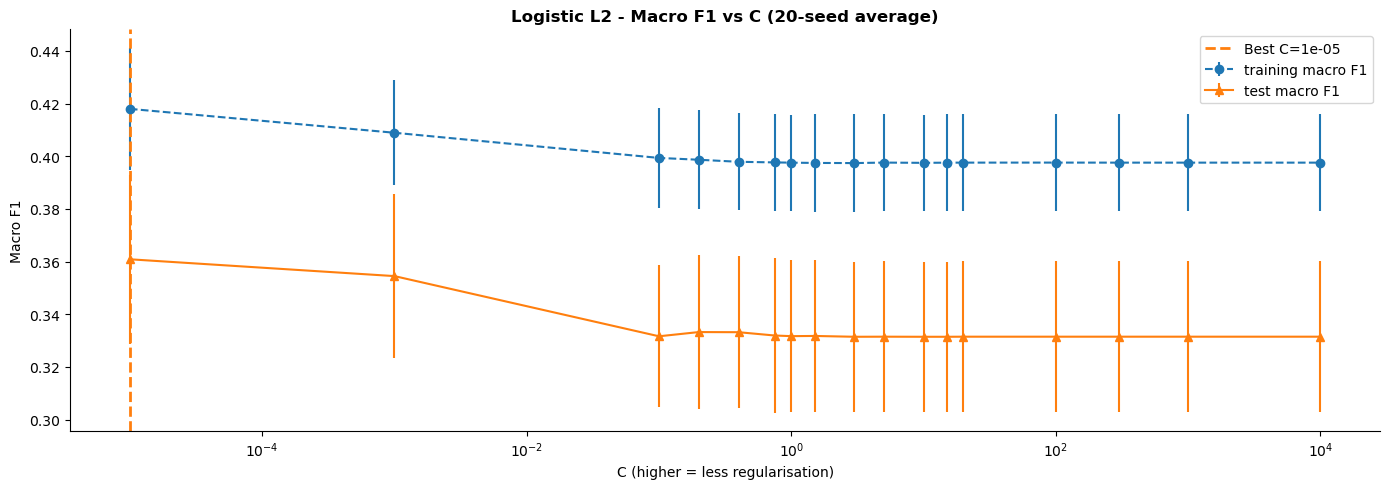

In [17]:
fig = plt.figure(figsize=(14, 5))
plt.xscale('log')
plt.errorbar(C_settings, all_training_lr2.mean(axis=1),
             yerr=all_training_lr2.std(axis=1), label='training macro F1', marker='o', linestyle='dashed')
plt.errorbar(C_settings, all_test_lr2.mean(axis=1),
             yerr=all_test_lr2.std(axis=1), label='test macro F1', marker='^')
plt.axvline(best_C_lr2, color='tab:orange', linestyle='--', lw=2, label=f'Best C={best_C_lr2}')
plt.ylabel('Macro F1')
plt.xlabel('C (higher = less regularisation)')
plt.title(f'Logistic L2 - Macro F1 vs C ({No_trials}-seed average)', fontweight='bold')
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

Logistic L2 (C=1e-05, class_weight='balanced')
  [Sweep]  Test macro F1: 0.3609 +/- 0.0321
  Train macro F1: 0.3781
  Test  macro F1: 0.4055


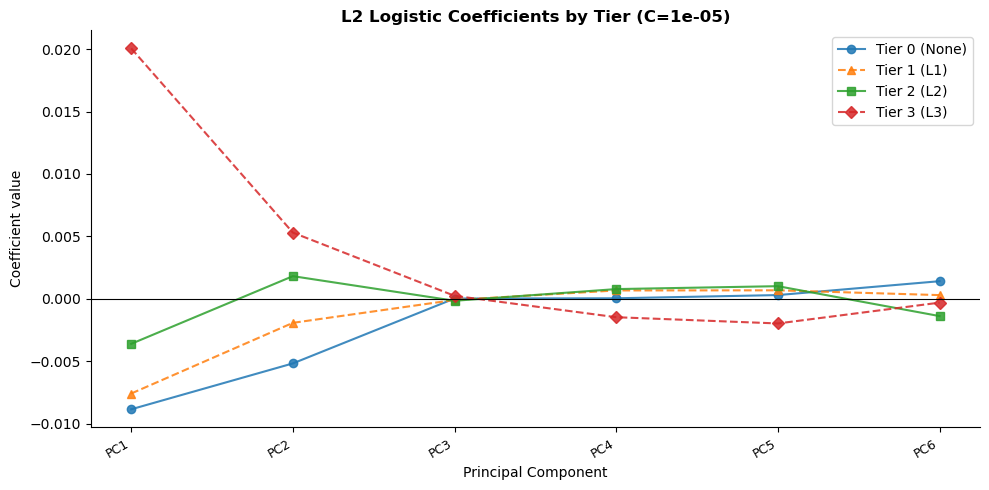

In [18]:
lr2_final = LogisticRegression(C=best_C_lr2, class_weight='balanced',
                                solver='lbfgs', max_iter=1000, random_state=42)
lr2_final.fit(X_train_pca, y_train_sweep)

lr2_train_f1 = f1_score(y_train_sweep, lr2_final.predict(X_train_pca), average='macro', zero_division=0)
lr2_test_f1  = f1_score(y_test,        lr2_final.predict(X_test_pca),  average='macro', zero_division=0)
lr2_sweep_f1  = all_test_lr2.mean(axis=1).max()
lr2_sweep_std = all_test_lr2.std(axis=1).iloc[np.argmax(all_test_lr2.mean(axis=1))]

print(f"Logistic L2 (C={best_C_lr2}, class_weight='balanced')")
print(f"  [Sweep]  Test macro F1: {lr2_sweep_f1:.4f} +/- {lr2_sweep_std:.4f}")
print(f"  Train macro F1: {lr2_train_f1:.4f}")
print(f"  Test  macro F1: {lr2_test_f1:.4f}")

markers    = ['-o', '--^', '-s', '--D']
tier_names = ['Tier 0 (None)', 'Tier 1 (L1)', 'Tier 2 (L2)', 'Tier 3 (L3)']
fig = plt.figure(figsize=(max(10, n_components * 1.2), 5))
for i, (name, marker) in enumerate(zip(tier_names, markers)):
    plt.plot(lr2_final.coef_[i], marker, label=name, alpha=0.85)
plt.xticks(range(n_components), [n.split('(')[0].strip() for n in pc_names], rotation=30, ha='right', fontsize=9)
plt.axhline(0, color='black', lw=0.8)
plt.xlabel('Principal Component')
plt.ylabel('Coefficient value')
plt.title(f'L2 Logistic Coefficients by Tier (C={best_C_lr2})', fontweight='bold')
plt.legend(fontsize=10)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

---
## 8. Model 3 — Logistic Regression with L1 Regularisation

Following **Notebook 3B** exactly: `penalty='l1'`, `solver='liblinear'`. Since `liblinear` is binary-only, we use `OneVsRestClassifier` — the professor's approach generalised to 4 classes. L1 drives PC coefficients to zero, revealing which components are redundant for each tier.

**This sweep completes in ~4 seconds** (vs 20+ minutes with `saga`).


In [19]:
all_training_lr1 = pd.DataFrame()
all_test_lr1     = pd.DataFrame()

for seedN in range(1, No_trials + 1):
    X_tr_raw, X_te_raw, y_tr_raw, y_te = train_test_split(
        X_all_sc, y_all, test_size=0.25, random_state=seedN, stratify=y_all
    )
    X_tr_sm, y_tr_sm = SMOTE(
        sampling_strategy={
            2: max((y_tr_raw == 2).sum(), (y_tr_raw == 1).sum() // 2),
            3: max((y_tr_raw == 3).sum(), (y_tr_raw == 1).sum() // 2),
        }, random_state=42, k_neighbors=3
    ).fit_resample(X_tr_raw, y_tr_raw)
    X_tr = pca.transform(X_tr_sm)
    X_te = pca.transform(X_te_raw)
    training_f1, test_f1 = [], []
    for C in C_settings:
        lr = OneVsRestClassifier(
            LogisticRegression(C=C, penalty='l1', solver='liblinear',
                               max_iter=1000, class_weight='balanced')
        )
        lr.fit(X_tr, y_tr_sm)
        training_f1.append(f1_score(y_tr_sm, lr.predict(X_tr), average='macro', zero_division=0))
        test_f1.append(    f1_score(y_te,    lr.predict(X_te), average='macro', zero_division=0))
    all_training_lr1[seedN] = training_f1
    all_test_lr1[seedN]     = test_f1

best_C_lr1 = C_settings[np.argmax(all_test_lr1.mean(axis=1))]
print(f"Highest Average Test Macro F1 = {np.amax(all_test_lr1.mean(axis=1)):.4f}")
print(f"Best C = {best_C_lr1}")

Highest Average Test Macro F1 = 0.3229
Best C = 0.1


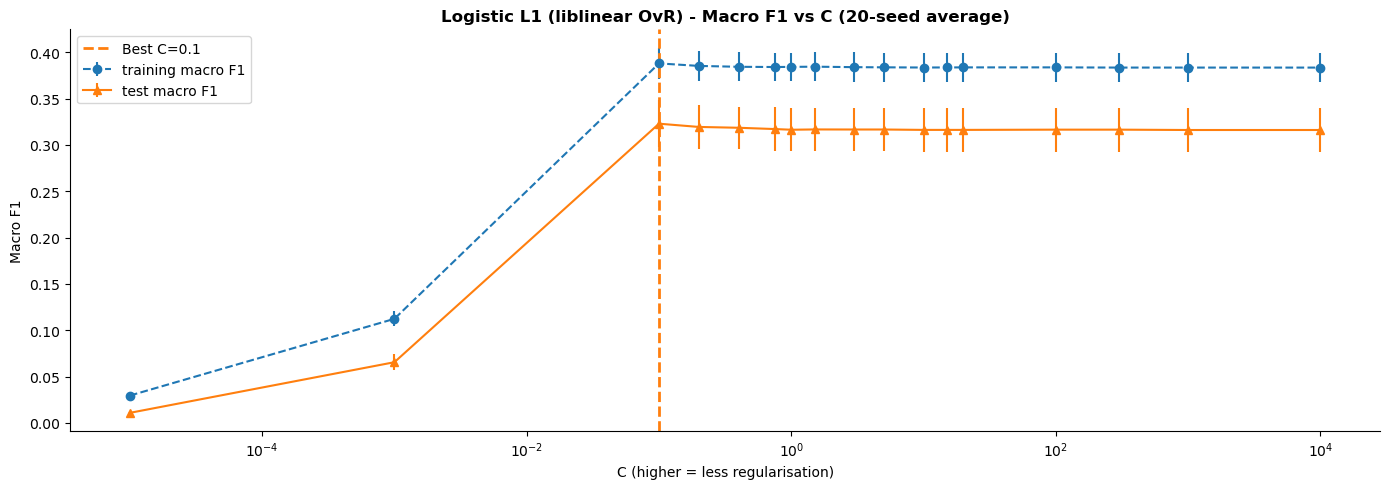

In [20]:
fig = plt.figure(figsize=(14, 5))
plt.xscale('log')
plt.errorbar(C_settings, all_training_lr1.mean(axis=1),
             yerr=all_training_lr1.std(axis=1), label='training macro F1', marker='o', linestyle='dashed')
plt.errorbar(C_settings, all_test_lr1.mean(axis=1),
             yerr=all_test_lr1.std(axis=1), label='test macro F1', marker='^')
plt.axvline(best_C_lr1, color='tab:orange', linestyle='--', lw=2, label=f'Best C={best_C_lr1}')
plt.ylabel('Macro F1')
plt.xlabel('C (higher = less regularisation)')
plt.title(f'Logistic L1 (liblinear OvR) - Macro F1 vs C ({No_trials}-seed average)', fontweight='bold')
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

Logistic L1 (C=0.1, liblinear OvR, class_weight='balanced')
  [Sweep]  Test macro F1: 0.3229 +/- 0.0255
  Train macro F1: 0.3956
  Test  macro F1: 0.3332

PC coefficients per tier (0 = excluded by L1 sparsity):
               PC1 (births_residence_m)  PC2 (beds_per_1000)  PC3 (beds_per_1000)  PC4 (facility_density_p)  PC5 (population_2020)  PC6 (pharmacy)
Tier 0 (None)                    -0.252               -0.458               -0.109                     0.088                  0.119           0.346
Tier 1 (L1)                      -0.167               -0.025               -0.043                     0.056                  0.095          -0.010
Tier 2 (L2)                      -0.078                0.185               -0.032                     0.171                  0.086          -0.486
Tier 3 (L3)                       0.232                0.429                0.000                    -0.054                 -0.862           0.000

Total coefficients zeroed out: 2/24


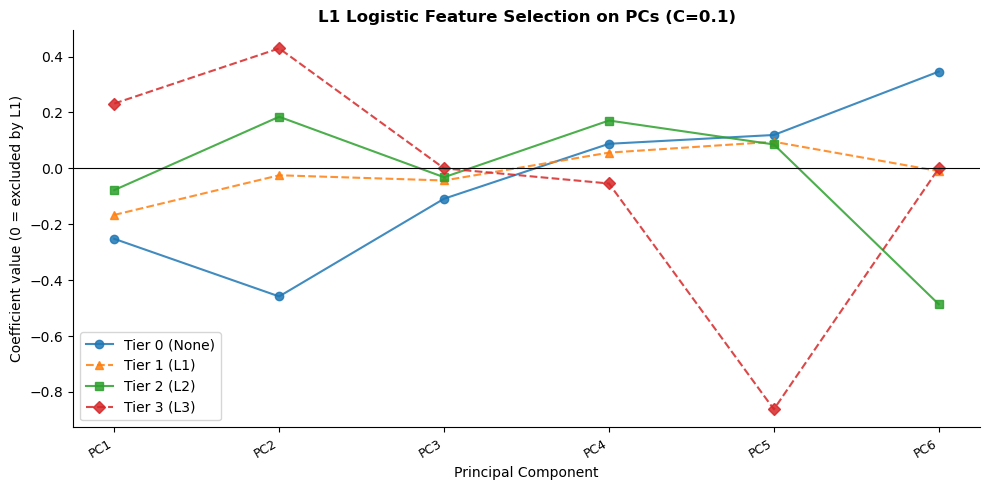

In [21]:
lr1_final = OneVsRestClassifier(
    LogisticRegression(C=best_C_lr1, penalty='l1', solver='liblinear',
                       max_iter=1000, class_weight='balanced')
)
lr1_final.fit(X_train_pca, y_train_sweep)

lr1_train_f1 = f1_score(y_train_sweep, lr1_final.predict(X_train_pca), average='macro', zero_division=0)
lr1_test_f1  = f1_score(y_test,        lr1_final.predict(X_test_pca),  average='macro', zero_division=0)
lr1_sweep_f1  = all_test_lr1.mean(axis=1).max()
lr1_sweep_std = all_test_lr1.std(axis=1).iloc[np.argmax(all_test_lr1.mean(axis=1))]

all_coefs = np.array([est.coef_[0] for est in lr1_final.estimators_])

print(f"Logistic L1 (C={best_C_lr1}, liblinear OvR, class_weight='balanced')")
print(f"  [Sweep]  Test macro F1: {lr1_sweep_f1:.4f} +/- {lr1_sweep_std:.4f}")
print(f"  Train macro F1: {lr1_train_f1:.4f}")
print(f"  Test  macro F1: {lr1_test_f1:.4f}")
print()
print("PC coefficients per tier (0 = excluded by L1 sparsity):")
coef_df = pd.DataFrame(all_coefs, index=tier_names,
                        columns=pc_names[:all_coefs.shape[1]])
print(coef_df.round(3).to_string())
zeroed = (all_coefs == 0).sum()
print(f"\nTotal coefficients zeroed out: {zeroed}/{all_coefs.size}")

fig = plt.figure(figsize=(max(10, n_components * 1.2), 5))
for i, (name, marker) in enumerate(zip(tier_names, markers)):
    plt.plot(all_coefs[i], marker, label=name, alpha=0.85)
plt.xticks(range(all_coefs.shape[1]),
           [n.split('(')[0].strip() for n in pc_names[:all_coefs.shape[1]]],
           rotation=30, ha='right', fontsize=9)
plt.axhline(0, color='black', lw=0.8)
plt.xlabel('Principal Component')
plt.ylabel('Coefficient value (0 = excluded by L1)')
plt.title(f'L1 Logistic Feature Selection on PCs (C={best_C_lr1})', fontweight='bold')
plt.legend(fontsize=10)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

---
## 9. Model 4 — Random Forest Classifier

Following **Notebook 4A**: scan `max_depth` over 20 seeds. Scale-invariant — PC scores are used directly. Produces feature importances showing which of the 4 named components matter most.


In [22]:
all_training_rf   = pd.DataFrame()
all_test_rf       = pd.DataFrame()
maxdepth_settings = range(1, 21)

for seedN in range(1, No_trials + 1):
    X_tr_raw, X_te_raw, y_tr_raw, y_te = train_test_split(
        X_all_sc, y_all, test_size=0.25, random_state=seedN, stratify=y_all
    )
    X_tr_sm, y_tr_sm = SMOTE(
        sampling_strategy={
            2: max((y_tr_raw == 2).sum(), (y_tr_raw == 1).sum() // 2),
            3: max((y_tr_raw == 3).sum(), (y_tr_raw == 1).sum() // 2),
        }, random_state=42, k_neighbors=3
    ).fit_resample(X_tr_raw, y_tr_raw)
    X_tr = pca.transform(X_tr_sm)
    X_te = pca.transform(X_te_raw)
    training_f1, test_f1 = [], []
    for depth in maxdepth_settings:
        rf = RandomForestClassifier(n_estimators=100, max_depth=depth,
                                    class_weight='balanced', random_state=0, n_jobs=-1)
        rf.fit(X_tr, y_tr_sm)
        training_f1.append(f1_score(y_tr_sm, rf.predict(X_tr), average='macro', zero_division=0))
        test_f1.append(    f1_score(y_te,    rf.predict(X_te), average='macro', zero_division=0))
    all_training_rf[seedN] = training_f1
    all_test_rf[seedN]     = test_f1

best_depth_rf = list(maxdepth_settings)[np.argmax(all_test_rf.mean(axis=1))]
print(f"Highest Average Test Macro F1 = {np.amax(all_test_rf.mean(axis=1)):.4f}")
print(f"Best max_depth = {best_depth_rf}")

Highest Average Test Macro F1 = 0.3843
Best max_depth = 9


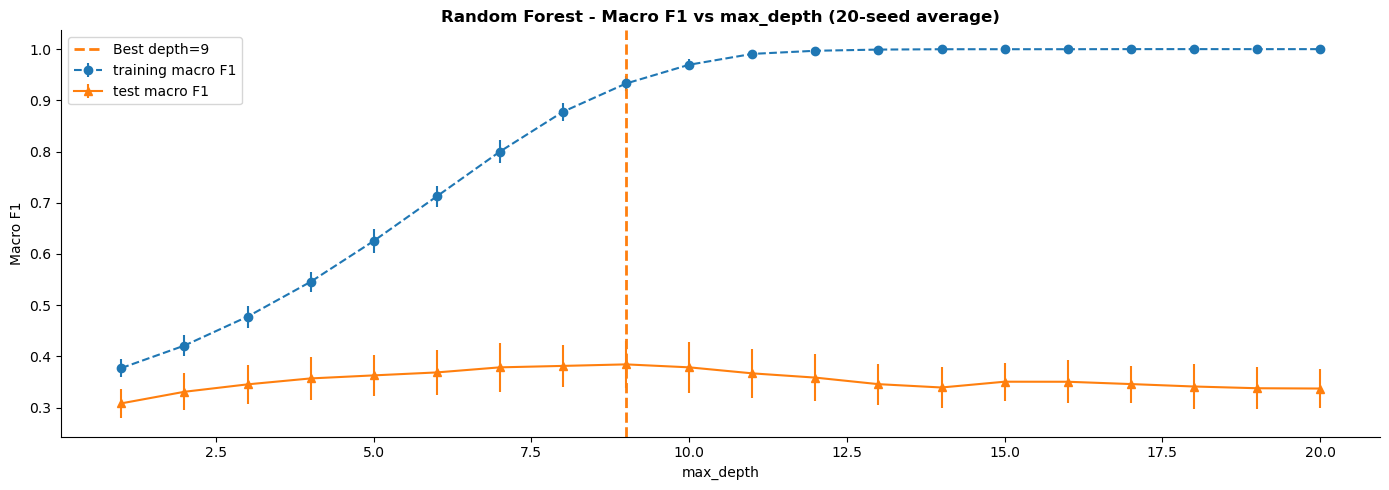

Decision: depth=9.


In [23]:
fig = plt.figure(figsize=(14, 5))
plt.errorbar(maxdepth_settings, all_training_rf.mean(axis=1),
             yerr=all_training_rf.std(axis=1), label='training macro F1', marker='o', linestyle='dashed')
plt.errorbar(maxdepth_settings, all_test_rf.mean(axis=1),
             yerr=all_test_rf.std(axis=1), label='test macro F1', marker='^')
plt.axvline(best_depth_rf, color='tab:orange', linestyle='--', lw=2, label=f'Best depth={best_depth_rf}')
plt.ylabel('Macro F1')
plt.xlabel('max_depth')
plt.title(f'Random Forest - Macro F1 vs max_depth ({No_trials}-seed average)', fontweight='bold')
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()
print(f"Decision: depth={best_depth_rf}.")

Random Forest (depth=9, 300 trees, class_weight='balanced')
  [Sweep]  Test macro F1: 0.3843 +/- 0.0464
  Train macro F1: 0.9163
  Test  macro F1: 0.3778


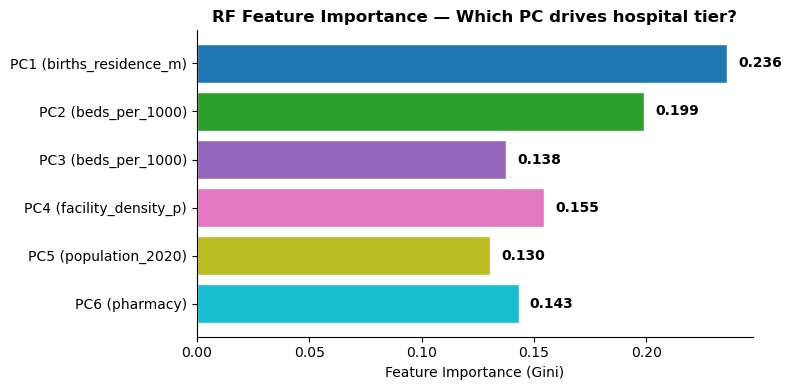

In [24]:
rf_final = RandomForestClassifier(n_estimators=300, max_depth=best_depth_rf,
                                   class_weight='balanced', random_state=0, n_jobs=-1)
rf_final.fit(X_train_pca, y_train_sweep)

rf_train_f1 = f1_score(y_train_sweep, rf_final.predict(X_train_pca), average='macro', zero_division=0)
rf_test_f1  = f1_score(y_test,        rf_final.predict(X_test_pca),  average='macro', zero_division=0)
rf_sweep_f1  = all_test_rf.mean(axis=1).max()
rf_sweep_std = all_test_rf.std(axis=1).iloc[np.argmax(all_test_rf.mean(axis=1))]

print(f"Random Forest (depth={best_depth_rf}, 300 trees, class_weight='balanced')")
print(f"  [Sweep]  Test macro F1: {rf_sweep_f1:.4f} +/- {rf_sweep_std:.4f}")
print(f"  Train macro F1: {rf_train_f1:.4f}")
print(f"  Test  macro F1: {rf_test_f1:.4f}")

fi = rf_final.feature_importances_
fi_colors = plt.cm.tab10(np.linspace(0, 1, n_components))
fig = plt.figure(figsize=(8, max(4, n_components * 0.45)))
bars = plt.barh(pc_names[::-1], fi[::-1], color=fi_colors[::-1], edgecolor='white')
for bar, val in zip(bars, fi[::-1]):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
plt.xlabel('Feature Importance (Gini)')
plt.title('RF Feature Importance — Which PC drives hospital tier?', fontweight='bold')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

---
## 10. Model 5 — Gradient Boosted Trees

Following **Notebook 4A**: GBM with `n_estimators=100`, `max_depth=3`, `learning_rate=0.1` by default. We scan `max_depth` over 20 seeds to tune, then display feature importances on the named PCs.


In [25]:
all_training_gbm   = pd.DataFrame()
all_test_gbm       = pd.DataFrame()
gbm_depth_settings = range(1, 6)

for seedN in range(1, No_trials + 1):
    X_tr_raw, X_te_raw, y_tr_raw, y_te = train_test_split(
        X_all_sc, y_all, test_size=0.25, random_state=seedN, stratify=y_all
    )
    t0_n = (y_tr_raw == 0).sum()
    smote_target = t0_n // 2
    X_tr_sm, y_tr_sm = SMOTE(
        sampling_strategy={
            1: max((y_tr_raw == 1).sum(), smote_target),
            2: max((y_tr_raw == 2).sum(), smote_target),
            3: max((y_tr_raw == 3).sum(), smote_target),
        }, random_state=42, k_neighbors=3
    ).fit_resample(X_tr_raw, y_tr_raw)
    X_tr = pca.transform(X_tr_sm)
    X_te = pca.transform(X_te_raw)
    training_f1, test_f1 = [], []
    for depth in gbm_depth_settings:
        gbm = GradientBoostingClassifier(n_estimators=200, max_depth=depth,
                                         learning_rate=0.1, random_state=42)
        gbm.fit(X_tr, y_tr_sm)
        training_f1.append(f1_score(y_tr_sm, gbm.predict(X_tr), average='macro', zero_division=0))
        test_f1.append(    f1_score(y_te,    gbm.predict(X_te), average='macro', zero_division=0))
    all_training_gbm[seedN] = training_f1
    all_test_gbm[seedN]     = test_f1

best_depth_gbm = list(gbm_depth_settings)[np.argmax(all_test_gbm.mean(axis=1))]
print(f"Highest Average Test Macro F1 = {np.amax(all_test_gbm.mean(axis=1)):.4f}")
print(f"Best max_depth = {best_depth_gbm}")

Highest Average Test Macro F1 = 0.3512
Best max_depth = 5


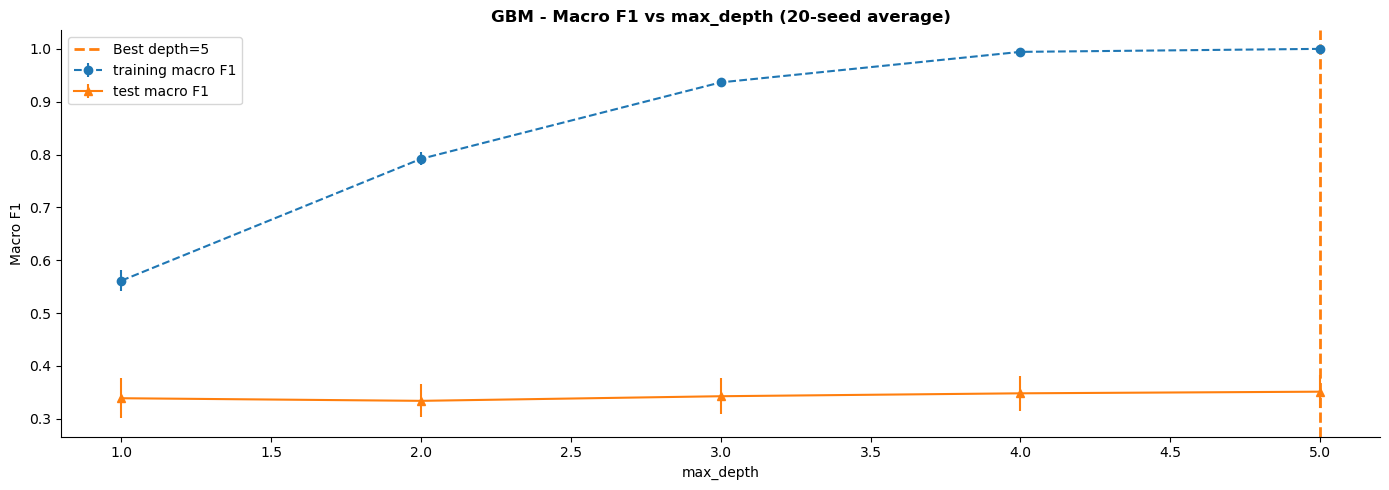

In [26]:
fig = plt.figure(figsize=(14, 5))
plt.errorbar(gbm_depth_settings, all_training_gbm.mean(axis=1),
             yerr=all_training_gbm.std(axis=1), label='training macro F1', marker='o', linestyle='dashed')
plt.errorbar(gbm_depth_settings, all_test_gbm.mean(axis=1),
             yerr=all_test_gbm.std(axis=1), label='test macro F1', marker='^')
plt.axvline(best_depth_gbm, color='tab:orange', linestyle='--', lw=2, label=f'Best depth={best_depth_gbm}')
plt.ylabel('Macro F1')
plt.xlabel('max_depth')
plt.title(f'GBM - Macro F1 vs max_depth ({No_trials}-seed average)', fontweight='bold')
plt.legend()
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

GBM (depth=5, 300 trees, lr=0.05, subsample=0.8)
  [Sweep]  Test macro F1: 0.3512 +/- 0.0308
  Train macro F1: 1.0000
  Test  macro F1: 0.3784


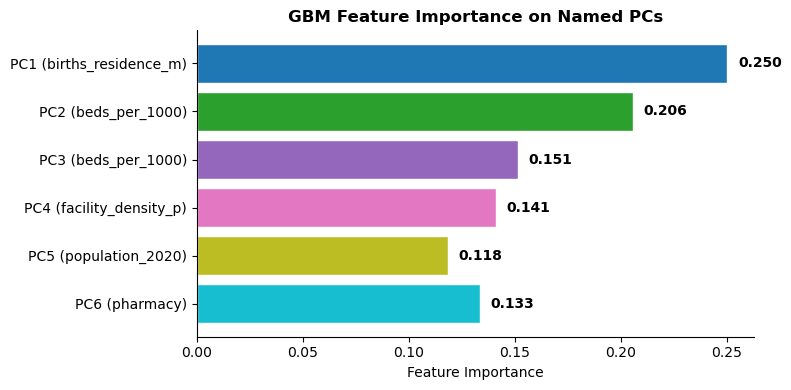

In [27]:
gbm_final = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=best_depth_gbm,
    learning_rate=0.05,      # slower learning = better generalisation
    subsample=0.8,           # stochastic boosting, helps minority tiers
    min_samples_leaf=3,      # prevents overfitting on tiny SMOTE clusters
    random_state=0
)
gbm_final.fit(X_train_pca, y_train_sweep)

gbm_train_f1 = f1_score(y_train_sweep, gbm_final.predict(X_train_pca), average='macro', zero_division=0)
gbm_test_f1  = f1_score(y_test,        gbm_final.predict(X_test_pca),  average='macro', zero_division=0)
gbm_sweep_f1  = all_test_gbm.mean(axis=1).max()
gbm_sweep_std = all_test_gbm.std(axis=1).iloc[np.argmax(all_test_gbm.mean(axis=1))]

print(f"GBM (depth={best_depth_gbm}, 300 trees, lr=0.05, subsample=0.8)")
print(f"  [Sweep]  Test macro F1: {gbm_sweep_f1:.4f} +/- {gbm_sweep_std:.4f}")
print(f"  Train macro F1: {gbm_train_f1:.4f}")
print(f"  Test  macro F1: {gbm_test_f1:.4f}")

fi_gbm = gbm_final.feature_importances_
fi_colors = plt.cm.tab10(np.linspace(0, 1, n_components))
fig = plt.figure(figsize=(8, max(4, n_components * 0.45)))
bars = plt.barh(pc_names[::-1], fi_gbm[::-1], color=fi_colors[::-1], edgecolor='white')
for bar, val in zip(bars, fi_gbm[::-1]):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=10, fontweight='bold')
plt.xlabel('Feature Importance')
plt.title('GBM Feature Importance on Named PCs', fontweight='bold')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

---
## 11. Model Comparison

In [28]:
model_names = [f'kNN (k={best_k})', f'Logistic L2 (C={best_C_lr2})',
               f'Logistic L1 (C={best_C_lr1})', f'RF (d={best_depth_rf})',
               f'GBM (d={best_depth_gbm})']
sweep_f1s  = [knn_sweep_f1,  lr2_sweep_f1,  lr1_sweep_f1,  rf_sweep_f1,  gbm_sweep_f1]
sweep_stds = [knn_sweep_std, lr2_sweep_std, lr1_sweep_std, rf_sweep_std, gbm_sweep_std]
train_f1s  = [knn_train_f1,  lr2_train_f1,  lr1_train_f1,  rf_train_f1,  gbm_train_f1]
test_f1s   = [knn_test_f1,   lr2_test_f1,   lr1_test_f1,   rf_test_f1,   gbm_test_f1]

results = pd.DataFrame({
    'Model':              model_names,
    'Sweep MacroF1(mean)': sweep_f1s,
    'Sweep MacroF1(std)':  sweep_stds,
    'Train MacroF1':       train_f1s,
    'Test MacroF1':        test_f1s,
    'Imbalance handling': ['SMOTE+distance'] + ['SMOTE+balanced'] * 4,
}).set_index('Model').round(4)

print(f"All models: SMOTE on Tier 2 & 3, class_weight='balanced', evaluated on macro F1.")
print()
print(results.to_string())
print()
print(f"Best model: {results['Sweep MacroF1(mean)'].idxmax()}")

All models: SMOTE on Tier 2 & 3, class_weight='balanced', evaluated on macro F1.

                       Sweep MacroF1(mean)  Sweep MacroF1(std)  Train MacroF1  Test MacroF1 Imbalance handling
Model                                                                                                         
kNN (k=3)                           0.3699              0.0305         1.0000        0.3546     SMOTE+distance
Logistic L2 (C=1e-05)               0.3609              0.0321         0.3781        0.4055     SMOTE+balanced
Logistic L1 (C=0.1)                 0.3229              0.0255         0.3956        0.3332     SMOTE+balanced
RF (d=9)                            0.3843              0.0464         0.9163        0.3778     SMOTE+balanced
GBM (d=5)                           0.3512              0.0308         1.0000        0.3784     SMOTE+balanced

Best model: RF (d=9)


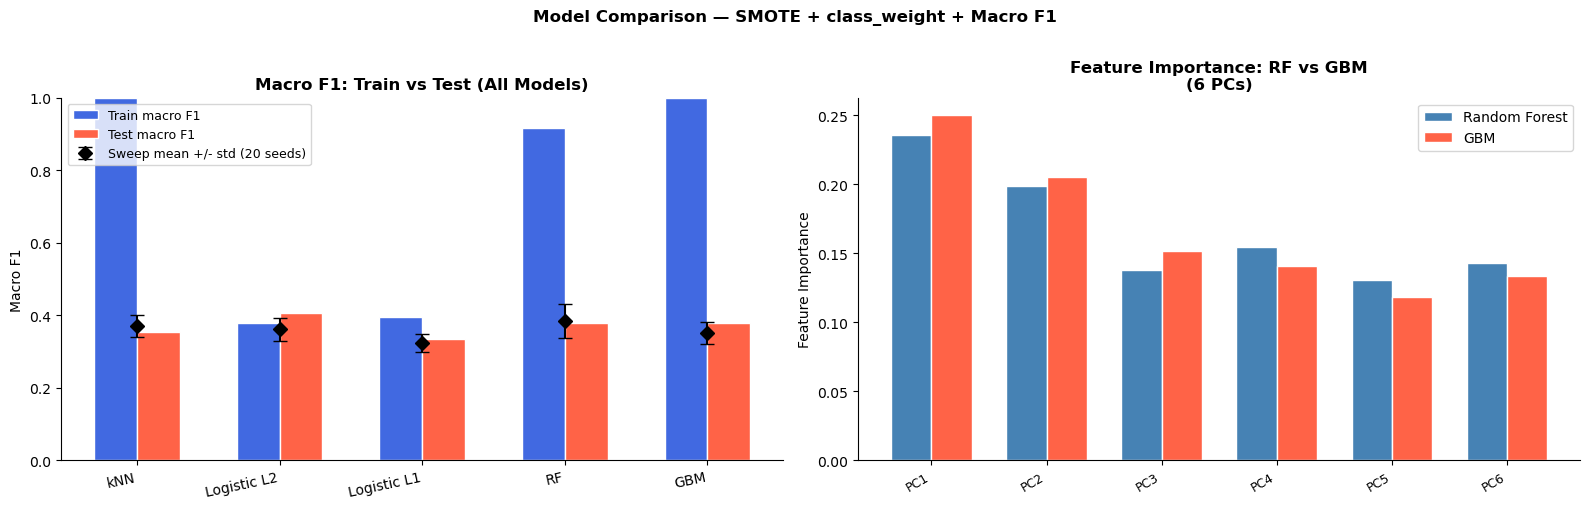

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = np.arange(len(results))
w = 0.30
axes[0].bar(x - w/2, results['Train MacroF1'], w, label='Train macro F1', color='royalblue', edgecolor='white')
axes[0].bar(x + w/2, results['Test MacroF1'],  w, label='Test macro F1',  color='tomato',    edgecolor='white')
axes[0].errorbar(x, results['Sweep MacroF1(mean)'], yerr=results['Sweep MacroF1(std)'],
                 fmt='D', color='black', markersize=7, capsize=5,
                 label=f'Sweep mean +/- std ({No_trials} seeds)')
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.split('(')[0].strip() for m in results.index], rotation=12, ha='right', fontsize=10)
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Macro F1: Train vs Test (All Models)', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.0)
axes[0].spines[['top', 'right']].set_visible(False)

fi_rf_arr  = rf_final.feature_importances_
fi_gbm_arr = gbm_final.feature_importances_
xi    = np.arange(n_components)
bar_w = min(0.35, 0.8 / 2)
axes[1].bar(xi - bar_w/2, fi_rf_arr,  bar_w, label='Random Forest', color='steelblue', edgecolor='white')
axes[1].bar(xi + bar_w/2, fi_gbm_arr, bar_w, label='GBM',           color='tomato',    edgecolor='white')
axes[1].set_xticks(xi)
axes[1].set_xticklabels([n.split('(')[0].strip() for n in pc_names], rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Feature Importance')
axes[1].set_title(f'Feature Importance: RF vs GBM\n({n_components} PCs)', fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Model Comparison — SMOTE + class_weight + Macro F1',
              fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

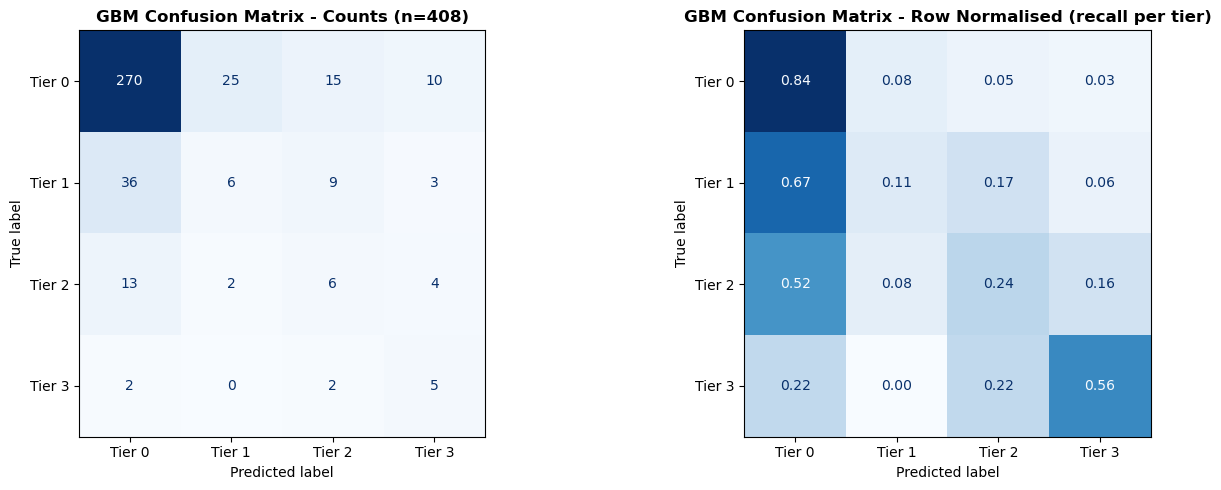

              precision    recall  f1-score   support

      Tier 0       0.84      0.84      0.84       320
      Tier 1       0.18      0.11      0.14        54
      Tier 2       0.19      0.24      0.21        25
      Tier 3       0.23      0.56      0.32         9

    accuracy                           0.70       408
   macro avg       0.36      0.44      0.38       408
weighted avg       0.70      0.70      0.70       408

Overall macro F1: 0.3784


In [30]:
y_pred_best = gbm_final.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm, display_labels=['Tier 0','Tier 1','Tier 2','Tier 3']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'GBM Confusion Matrix - Counts (n={len(y_test)})', fontweight='bold')

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=['Tier 0','Tier 1','Tier 2','Tier 3']).plot(
    ax=axes[1], colorbar=False, cmap='Blues', values_format='.2f')
axes[1].set_title('GBM Confusion Matrix - Row Normalised (recall per tier)', fontweight='bold')
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred_best,
      target_names=['Tier 0','Tier 1','Tier 2','Tier 3'], zero_division=0))
print(f"Overall macro F1: {f1_score(y_test, y_pred_best, average='macro', zero_division=0):.4f}")

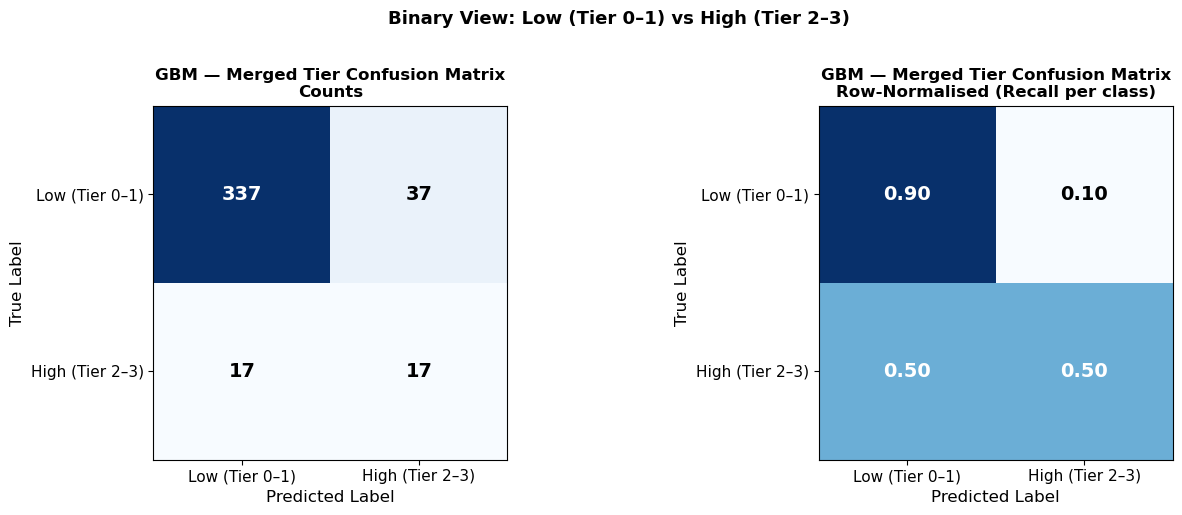

Merged-Tier Classification Summary (GBM, test set)
Class               Precision   Recall       F1
-------------------------------------------------------
  Low (Tier 0–1)        0.952    0.901    0.926
  High (Tier 2–3)       0.315    0.500    0.386
-------------------------------------------------------
  Macro avg                               0.656

TN (Low predicted Low) : 337
FP (Low predicted High): 37
FN (High predicted Low): 17
TP (High predicted High): 17


In [31]:
# ── 11b. Merged-Tier Confusion Matrix (0–1 vs 2–3) ──────────────────────
#
# Rationale: Tier 2 & 3 are rare (4.5% + 1.3%) and frequently confused
# with each other. Merging into a binary "Low (0–1) vs High (2–3)" frame
# shows whether the model can identify LGUs that genuinely need higher-level
# hospitals — the clinically meaningful distinction.

import itertools

# Map original 4-class predictions to binary
def merge_tiers(arr):
    return np.where(np.array(arr) <= 1, 0, 1)

y_test_bin = merge_tiers(y_test)
y_pred_bin = merge_tiers(y_pred_best)

bin_labels = ['Low (Tier 0–1)', 'High (Tier 2–3)']
cm_bin     = confusion_matrix(y_test_bin, y_pred_bin)
cm_bin_norm = cm_bin.astype(float) / cm_bin.sum(axis=1, keepdims=True)

# ── Compute per-class metrics ─────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score as f1

prec_bin = precision_score(y_test_bin, y_pred_bin, average=None, zero_division=0)
rec_bin  = recall_score(y_test_bin, y_pred_bin, average=None, zero_division=0)
f1_bin   = f1(y_test_bin, y_pred_bin, average=None, zero_division=0)
f1_macro = f1(y_test_bin, y_pred_bin, average='macro', zero_division=0)

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mat, fmt, title in [
    (axes[0], cm_bin,      'd',    'Counts'),
    (axes[1], cm_bin_norm, '.2f',  'Row-Normalised (Recall per class)'),
]:
    im = ax.imshow(mat, interpolation='nearest', cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(bin_labels, fontsize=11)
    ax.set_yticklabels(bin_labels, fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(f'GBM — Merged Tier Confusion Matrix\n{title}', fontweight='bold')
    thresh = mat.max() / 2.0
    for i, j in itertools.product(range(2), range(2)):
        val = format(mat[i, j], fmt)
        ax.text(j, i, val, ha='center', va='center', fontsize=14, fontweight='bold',
                color='white' if mat[i, j] > thresh else 'black')

plt.suptitle('Binary View: Low (Tier 0–1) vs High (Tier 2–3)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────
print("=" * 55)
print("Merged-Tier Classification Summary (GBM, test set)")
print("=" * 55)
print(f"{'Class':<18} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 55)
for i, lbl in enumerate(bin_labels):
    print(f"  {lbl:<16} {prec_bin[i]:>10.3f} {rec_bin[i]:>8.3f} {f1_bin[i]:>8.3f}")
print("-" * 55)
print(f"  {'Macro avg':<16} {'':>10} {'':>8} {f1_macro:>8.3f}")
print()
print("TN (Low predicted Low) :", cm_bin[0, 0])
print("FP (Low predicted High):", cm_bin[0, 1])
print("FN (High predicted Low):", cm_bin[1, 0])
print("TP (High predicted High):", cm_bin[1, 1])

---
## 12. Underserved LGU Identification

In [32]:
pred_full  = gbm_final.predict(X_all_pca)
proba_full = gbm_final.predict_proba(X_all_pca)

model_df = model_df.copy().reset_index(drop=True)
model_df['pred_tier']     = pred_full
model_df['tier_gap']      = model_df['pred_tier'] - model_df['tier']
model_df['expected_tier'] = (proba_full * np.array([0, 1, 2, 3])).sum(axis=1)

print("Tier gap (predicted - actual) distribution:")
print(model_df['tier_gap'].value_counts().sort_index())
print()

underserved  = model_df[model_df['tier_gap'] > 0].sort_values('expected_tier', ascending=False)
appropriate  = model_df[model_df['tier_gap'] == 0]
oversupplied = model_df[model_df['tier_gap'] < 0]

print(f"Underserved  (pred > actual): {len(underserved):>4} LGUs  <- priority for new hospitals")
print(f"Appropriate  (pred = actual): {len(appropriate):>4} LGUs")
print(f"Oversupplied (pred < actual): {len(oversupplied):>4} LGUs")


Tier gap (predicted - actual) distribution:
tier_gap
-3       2
-2      13
-1      40
 0    1508
 1      38
 2      18
 3      10
Name: count, dtype: int64

Underserved  (pred > actual):   66 LGUs  <- priority for new hospitals
Appropriate  (pred = actual): 1508 LGUs
Oversupplied (pred < actual):   55 LGUs


In [33]:
us = underserved[['city_municipality', 'region', 'tier', 'pred_tier',
                   'tier_gap', 'expected_tier', 'poverty_incidence_2023_pct']].copy()
us.columns = ['LGU', 'Region', 'Actual', 'Predicted', 'Gap', 'Exp. Tier', 'Poverty 2023 (%)']
us['Exp. Tier'] = us['Exp. Tier'].round(3)
us['Poverty 2023 (%)'] = us['Poverty 2023 (%)'].round(1)
print("UNDERSERVED LGUs (predicted tier > actual, sorted by Expected Tier):")
print(us.to_string(index=False))


UNDERSERVED LGUs (predicted tier > actual, sorted by Expected Tier):
                  LGU                                                  Region  Actual  Predicted  Gap  Exp. Tier  Poverty 2023 (%)
         CITY OF LIPA                                REGION IV-A (CALABARZON)       2          3    1      2.950               5.0
            BONIFACIO                            REGION X (NORTHERN MINDANAO)       0          3    3      2.696              37.4
       CITY OF OZAMIZ                            REGION X (NORTHERN MINDANAO)       0          3    3      2.671              23.2
             PAOMBONG                              REGION III (CENTRAL LUZON)       0          3    3      2.658              10.7
               MALVAR                                REGION IV-A (CALABARZON)       1          3    2      2.339               5.8
       CITY OF CAVITE                                REGION IV-A (CALABARZON)       2          3    1      2.294              11.9
             P

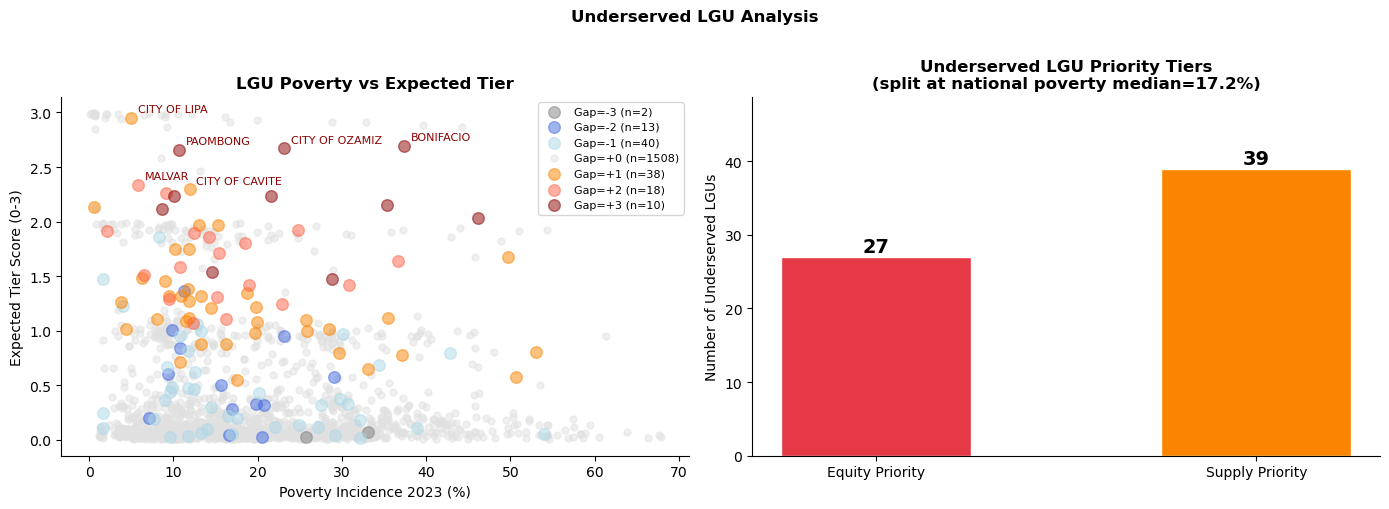

Equity priority (underserved + poverty > 17.2%): 27 LGUs
Supply priority (underserved + poverty <= 17.2%): 39 LGUs


In [34]:
# Poverty stratification among underserved
pov_median = model_df['poverty_incidence_2023_pct'].median()
eq_prio  = underserved[underserved['poverty_incidence_2023_pct'] >  pov_median]
sup_prio = underserved[underserved['poverty_incidence_2023_pct'] <= pov_median]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gap_colors = {-2:'royalblue', -1:'lightblue', 0:'#e0e0e0', 1:'#fb8500', 2:'tomato', 3:'darkred'}
for gap_val, subset in model_df.groupby('tier_gap'):
    axes[0].scatter(subset['poverty_incidence_2023_pct'], subset['expected_tier'],
                    color=gap_colors.get(gap_val, 'grey'), alpha=0.5,
                    s=25 if gap_val == 0 else 70,
                    label=f'Gap={gap_val:+d} (n={len(subset)})',
                    zorder=3 if abs(gap_val) > 0 else 1)
for _, row in underserved.head(6).iterrows():
    axes[0].annotate(row['city_municipality'],
                     (row['poverty_incidence_2023_pct'], row['expected_tier']),
                     fontsize=8, xytext=(5, 4), textcoords='offset points', color='darkred')
axes[0].set_xlabel('Poverty Incidence 2023 (%)')
axes[0].set_ylabel('Expected Tier Score (0-3)')
axes[0].set_title('LGU Poverty vs Expected Tier', fontweight='bold')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].spines[['top', 'right']].set_visible(False)

cat_labels = ['Equity Priority', 'Supply Priority']
cat_counts = [len(eq_prio), len(sup_prio)]
cat_colors = ['#e63946', '#fb8500']
bars2 = axes[1].bar(cat_labels, cat_counts, color=cat_colors, edgecolor='white', width=0.5)
for bar, cnt in zip(bars2, cat_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 str(cnt), ha='center', va='bottom', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Underserved LGUs')
axes[1].set_title(f'Underserved LGU Priority Tiers\n(split at national poverty median={pov_median:.1f}%)',
                   fontweight='bold')
axes[1].set_ylim(0, max(cat_counts) * 1.25)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Underserved LGU Analysis', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print(f"Equity priority (underserved + poverty > {pov_median:.1f}%): {len(eq_prio)} LGUs")
print(f"Supply priority (underserved + poverty <= {pov_median:.1f}%): {len(sup_prio)} LGUs")


---
## 13. Novelty — Expected Tier and PC2 Poverty Equity Analysis

### Expected Tier as a Continuous Underservice Score

The model produces four probabilities per LGU: P(Tier 0), P(Tier 1), P(Tier 2), P(Tier 3). These sum to 1. The **Expected Tier** is their weighted average:

$$E[tier] = P(T=0) \times 0 + P(T=1) \times 1 + P(T=2) \times 2 + P(T=3) \times 3$$

This converts a discrete 4-class prediction into a **continuous priority score**. Among underserved LGUs, those with higher expected tier are more urgently underserved. Not achievable with three separate binary classifiers.

### PC2 (Poverty) as Equity Lens

PC2 is the pure poverty axis. A higher PC2 score = higher poverty incidence. We can now ask: across all LGUs, does a higher poverty axis score predict a *lower* tier? If yes, that is the equity finding — poverty suppresses hospital tier independently of birth demand, city size, and growth.


In [35]:
# ── Find which PC best captures poverty (highest loading on poverty features) ──
poverty_feats = ['poverty_incidence_2018_pct', 'poverty_incidence_2021_pct', 'poverty_incidence_2023_pct']
pov_feat_idx  = [FEATURES.index(f) for f in poverty_feats if f in FEATURES]

pov_loadings_per_pc = []
for row in pca.components_:
    pov_loadings_per_pc.append(np.abs(row[pov_feat_idx]).mean())
poverty_pc_idx = int(np.argmax(pov_loadings_per_pc))
poverty_pc_name = pc_names[poverty_pc_idx]

print(f"Poverty axis identified: {poverty_pc_name} (index {poverty_pc_idx})")
print(f"  Mean absolute loading on poverty features: {pov_loadings_per_pc[poverty_pc_idx]:.3f}")
print()

# PC scores for the poverty axis
pc_pov_scores = X_all_pca[:, poverty_pc_idx]

print(f"{poverty_pc_name} score by actual tier:")
for t in [0, 1, 2, 3]:
    mask = (y_all == t).values
    med  = np.median(pc_pov_scores[mask])
    mn   = pc_pov_scores[mask].mean()
    print(f"  Tier {t} ({labels[t]:<22}): median = {med:+.3f},  mean = {mn:+.3f}")

print()
print("Interpretation:")
print("  Positive score = higher poverty. Negative score = lower poverty.")
print("  If higher tiers show lower scores, poverty suppresses tier.")


Poverty axis identified: PC3 (beds_per_1000) (index 2)
  Mean absolute loading on poverty features: 0.454

PC3 (beds_per_1000) score by actual tier:
  Tier 0 (No hospital           ): median = -0.160,  mean = +0.032
  Tier 1 (Level 1 (primary)     ): median = -0.241,  mean = +0.006
  Tier 2 (Level 2 (secondary)   ): median = -0.482,  mean = -0.034
  Tier 3 (Level 3 (tertiary)    ): median = -0.426,  mean = +0.285

Interpretation:
  Positive score = higher poverty. Negative score = lower poverty.
  If higher tiers show lower scores, poverty suppresses tier.


In [36]:
# Statistical tests
pov_raw = [model_df[model_df['tier']==t]['poverty_incidence_2023_pct'].dropna().values for t in range(4)]
stat_kw, p_kw = stats.kruskal(*pov_raw)
stat_mw, p_mw = stats.mannwhitneyu(pov_raw[0], pov_raw[3], alternative='greater')

print(f"Kruskal-Wallis (poverty differs across tiers): H={stat_kw:.1f}, p={p_kw:.2e}")
print(f"Mann-Whitney (Tier 0 poverty > Tier 3 poverty): p={p_mw:.2e}")
print()
print("Poverty incidence 2023 by tier:")
for t, vals in enumerate(pov_raw):
    print(f"  Tier {t}: mean={vals.mean():.1f}%  median={np.median(vals):.1f}%")


Kruskal-Wallis (poverty differs across tiers): H=50.3, p=6.84e-11
Mann-Whitney (Tier 0 poverty > Tier 3 poverty): p=3.58e-08

Poverty incidence 2023 by tier:
  Tier 0: mean=20.7%  median=18.7%
  Tier 1: mean=18.5%  median=14.5%
  Tier 2: mean=15.8%  median=13.3%
  Tier 3: mean=10.6%  median=7.7%


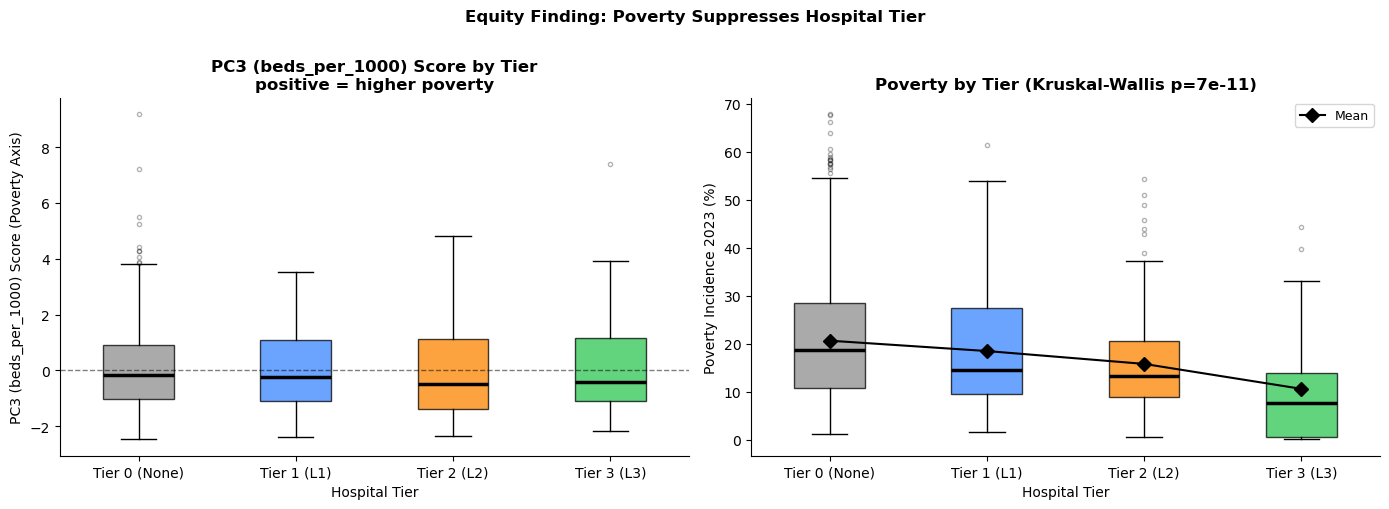

Both panels confirm the equity finding.
Higher-tier hospitals are concentrated in lower-poverty LGUs.


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PC2 (poverty axis) by tier — the equity finding via PCA scores
pc2_by_tier = [pc_pov_scores[(y_all == t).values] for t in range(4)]
bp = axes[0].boxplot(pc2_by_tier, labels=TIER_LBLS, patch_artist=True,
                      medianprops=dict(color='black', linewidth=2.5),
                      flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch, c in zip(bp['boxes'], TIER_COLORS):
    patch.set_facecolor(c); patch.set_alpha(0.75)
axes[0].axhline(0, color='black', linestyle='--', lw=1, alpha=0.5)
axes[0].set_ylabel(f'{poverty_pc_name} Score (Poverty Axis)')
axes[0].set_xlabel('Hospital Tier')
axes[0].set_title(f'{poverty_pc_name} Score by Tier\npositive = higher poverty', fontweight='bold')
axes[0].spines[['top', 'right']].set_visible(False)

# Right: raw poverty by tier  
bp2 = axes[1].boxplot(pov_raw, labels=TIER_LBLS, patch_artist=True,
                       medianprops=dict(color='black', linewidth=2.5),
                       flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch, c in zip(bp2['boxes'], TIER_COLORS):
    patch.set_facecolor(c); patch.set_alpha(0.75)
means = [v.mean() for v in pov_raw]
axes[1].plot(range(1,5), means, 'D-', color='black', ms=7, zorder=5, label='Mean')
axes[1].set_ylabel('Poverty Incidence 2023 (%)')
axes[1].set_xlabel('Hospital Tier')
axes[1].set_title(f'Poverty by Tier (Kruskal-Wallis p={p_kw:.0e})', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Equity Finding: Poverty Suppresses Hospital Tier', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()
print("Both panels confirm the equity finding.")
print("Higher-tier hospitals are concentrated in lower-poverty LGUs.")


---
## 14. Conclusion

In [38]:
print("=" * 68)
print("FINAL MODEL SUMMARY")
print("=" * 68)
print()
print(f"Input:  {n_components} PCA components from {len(FEATURES)} features")
print("Imbalance: SMOTE on Tier 2 & 3 (train only) + class_weight='balanced'")
print("Metric: Macro F1 (treats all tiers equally regardless of size)")
print("Target: Ordinal tier (0=none, 1=L1, 2=L2, 3=L3)")
print("Split:  75/25 stratified on tier, 20-seed sweep")
print()
print(f"{'Model':<38} {'Sweep F1':>10} {'Std':>7} {'Test F1':>10}")
print("-" * 68)
best_f1 = max(sweep_f1s)
for name, sf1, sstd, tf1 in zip(model_names, sweep_f1s, sweep_stds, test_f1s):
    flag = "  <- BEST" if sf1 == best_f1 else ""
    print(f"  {name:<36} {sf1:>10.4f} {sstd:>7.4f} {tf1:>10.4f}{flag}")

print()
print("ACTIONABLE OUTPUT:")
print(f"  Underserved LGUs (predicted tier > actual): {len(underserved)}")
print(f"    Equity priority (underserved + high poverty): {len(eq_prio)}")
print(f"    Supply priority (underserved + lower poverty): {len(sup_prio)}")
print()
print("EQUITY FINDING:")
print(f"  Kruskal-Wallis: poverty differs significantly across tiers (p={p_kw:.0e})")
print(f"  Tier 0: {pov_raw[0].mean():.1f}% poverty -> Tier 3: {pov_raw[3].mean():.1f}% poverty")
print()
print("DESIGN DECISIONS:")
print("  SMOTE applied to training set only — test set is never touched.")
print("  class_weight='balanced' on all classifiers that support it.")
print("  kNN uses weights='distance' as proxy for class weighting.")
print("  Macro F1 penalises ignoring rare tiers (T2, T3) equally.")
print("=" * 68)

FINAL MODEL SUMMARY

Input:  6 PCA components from 17 features
Imbalance: SMOTE on Tier 2 & 3 (train only) + class_weight='balanced'
Metric: Macro F1 (treats all tiers equally regardless of size)
Target: Ordinal tier (0=none, 1=L1, 2=L2, 3=L3)
Split:  75/25 stratified on tier, 20-seed sweep

Model                                    Sweep F1     Std    Test F1
--------------------------------------------------------------------
  kNN (k=3)                                0.3699  0.0305     0.3546
  Logistic L2 (C=1e-05)                    0.3609  0.0321     0.4055
  Logistic L1 (C=0.1)                      0.3229  0.0255     0.3332
  RF (d=9)                                 0.3843  0.0464     0.3778  <- BEST
  GBM (d=5)                                0.3512  0.0308     0.3784

ACTIONABLE OUTPUT:
  Underserved LGUs (predicted tier > actual): 66
    Equity priority (underserved + high poverty): 27
    Supply priority (underserved + lower poverty): 39

EQUITY FINDING:
  Kruskal-Wallis: pove